### [ 적응형 임계값 - blockSize, C 파라미터에 따른 성능 변화 ] <hr>

- 함수
    * cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)
- 파라미터
    * blockSize : 임계값 계산에 사용할 이웃 영역 크기 , 홀수, 3 이상 
    * C:  평균/가중평균에서 빼는 상수 (미세 조정). 보통 2~10 

- 원리
    * 단순 임계값
        - 이미지 전체에 하나의 threshold 적용 
        - 조명 불균일 시 한쪽은 다 흰색, 한쪽은 다 검정
    * 적응형 임계값
        - 각 픽셀 주변 blockSize × blockSize 영역의 평균을 계산
        - threshold = 해당 영역 평균 - C
        - 조명이 달라도 각 영역에서 상대적으로 판단

In [1]:
## ----------------------------------------
## 모듈 로딩
## ----------------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import koreanize_matplotlib


이미지 크기  : (480, 640)
dtype       : uint8
픽셀값 범위  : min=0, max=234, mean=114.7


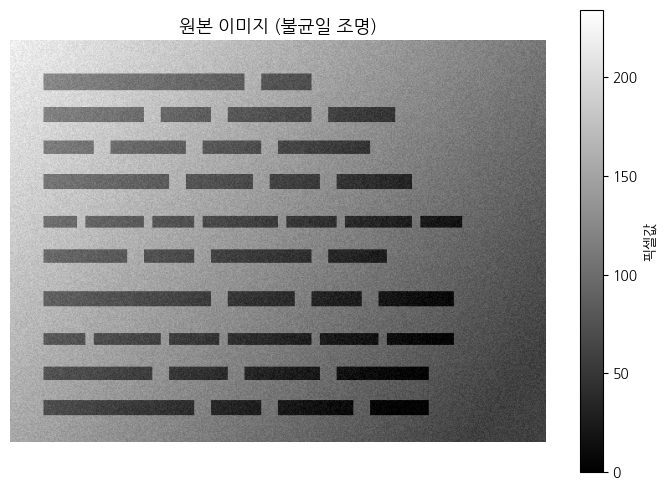

In [3]:
## ----------------------------------------
## 이미지 로딩 & 기본 정보 확인
## ----------------------------------------
IMG_FILE = '../Images/adaptive_thresh_sample.jpg'   

imgGray = cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)

if imgGray is None:
    raise FileNotFoundError(f'이미지를 찾을 수 없습니다: {IMG_FILE}')

print(f'이미지 크기  : {imgGray.shape}')
print(f'dtype       : {imgGray.dtype}')
print(f'픽셀값 범위  : min={imgGray.min()}, max={imgGray.max()}, mean={imgGray.mean():.1f}')

# 원본 확인
plt.figure(figsize=(7, 5))
plt.imshow(imgGray, cmap='gray')
plt.title('원본 이미지 (불균일 조명)', fontsize=13)
plt.colorbar(label='픽셀값')
plt.axis('off')
plt.tight_layout()
plt.show()

### [1] 단순 임계값 vs 적응형 임계값 비교 

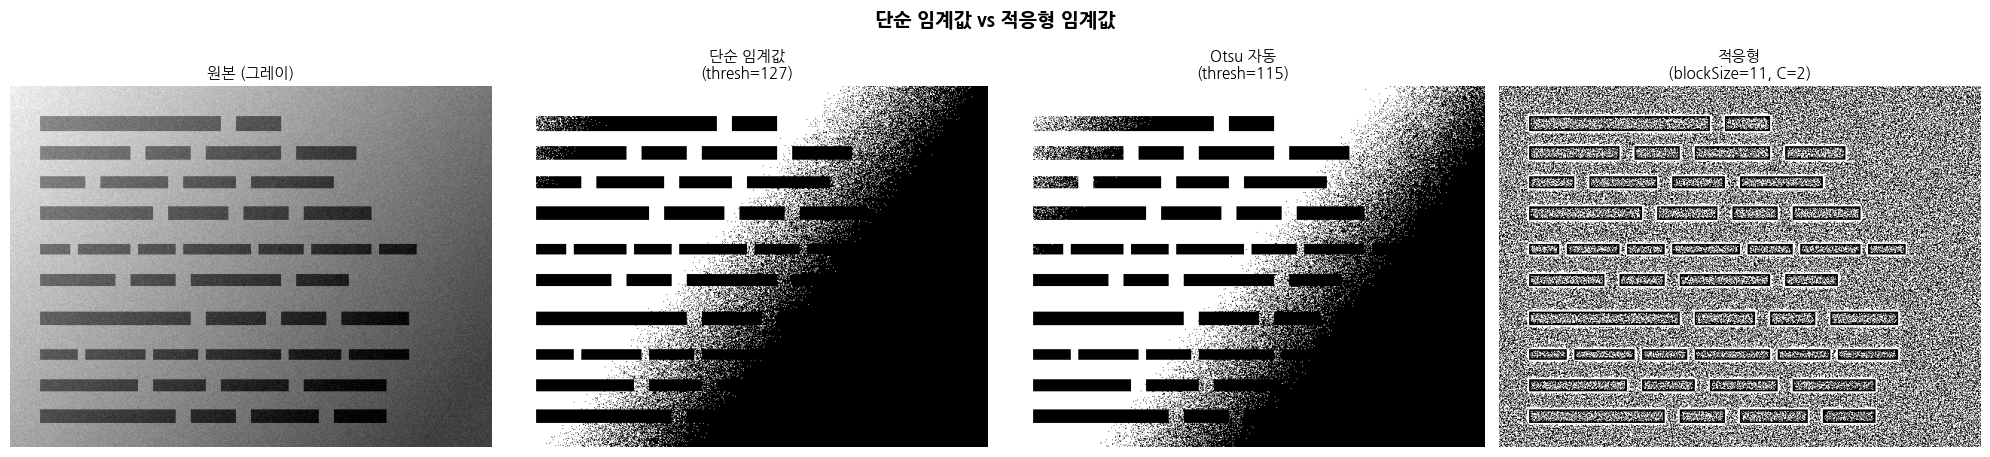

→ 단순 임계값: 조명 불균일로 인해 어두운 영역이 뭉개짐
→ 적응형 임계값: 각 영역 평균 기준으로 판단 → 균일하게 검출


In [4]:
# 단순 임계값 (전체에 하나의 기준)
_, mask_binary = cv2.threshold(imgGray, 127, 255, cv2.THRESH_BINARY)
otsu_val, mask_otsu = cv2.threshold(imgGray, 0, 255,
                                     cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 적응형 임계값 (기본값)
mask_adaptive = cv2.adaptiveThreshold(
    imgGray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,   # 기본 blockSize
    C=2             # 기본 C
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('단순 임계값 vs 적응형 임계값', fontsize=14, fontweight='bold')

data = [
    (imgGray,      '원본 (그레이)',             'gray'),
    (mask_binary,  '단순 임계값\n(thresh=127)', 'gray'),
    (mask_otsu,    f'Otsu 자동\n(thresh={otsu_val:.0f})', 'gray'),
    (mask_adaptive,'적응형\n(blockSize=11, C=2)', 'gray'),
]

for ax, (img, title, cmap) in zip(axes, data):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('result_step1_compare.jpg', dpi=120, bbox_inches='tight')
plt.show()

print(f'→ 단순 임계값: 조명 불균일로 인해 어두운 영역이 뭉개짐')
print(f'→ 적응형 임계값: 각 영역 평균 기준으로 판단 → 균일하게 검출')

### [2] blockSize 변화에 따른 영향

- blockSize : 임계값 계산에 사용할 이웃 영역 크기 (홀수만 가능)
- 작은 blockSize (3~11)  → 좁은 영역 기준 → 세밀한 패턴 검출, 노이즈에 민감
- 큰  blockSize (51~)   → 넓은 영역 기준 → 넓은 조명 변화 대응, 세부 묻힐 수 있음


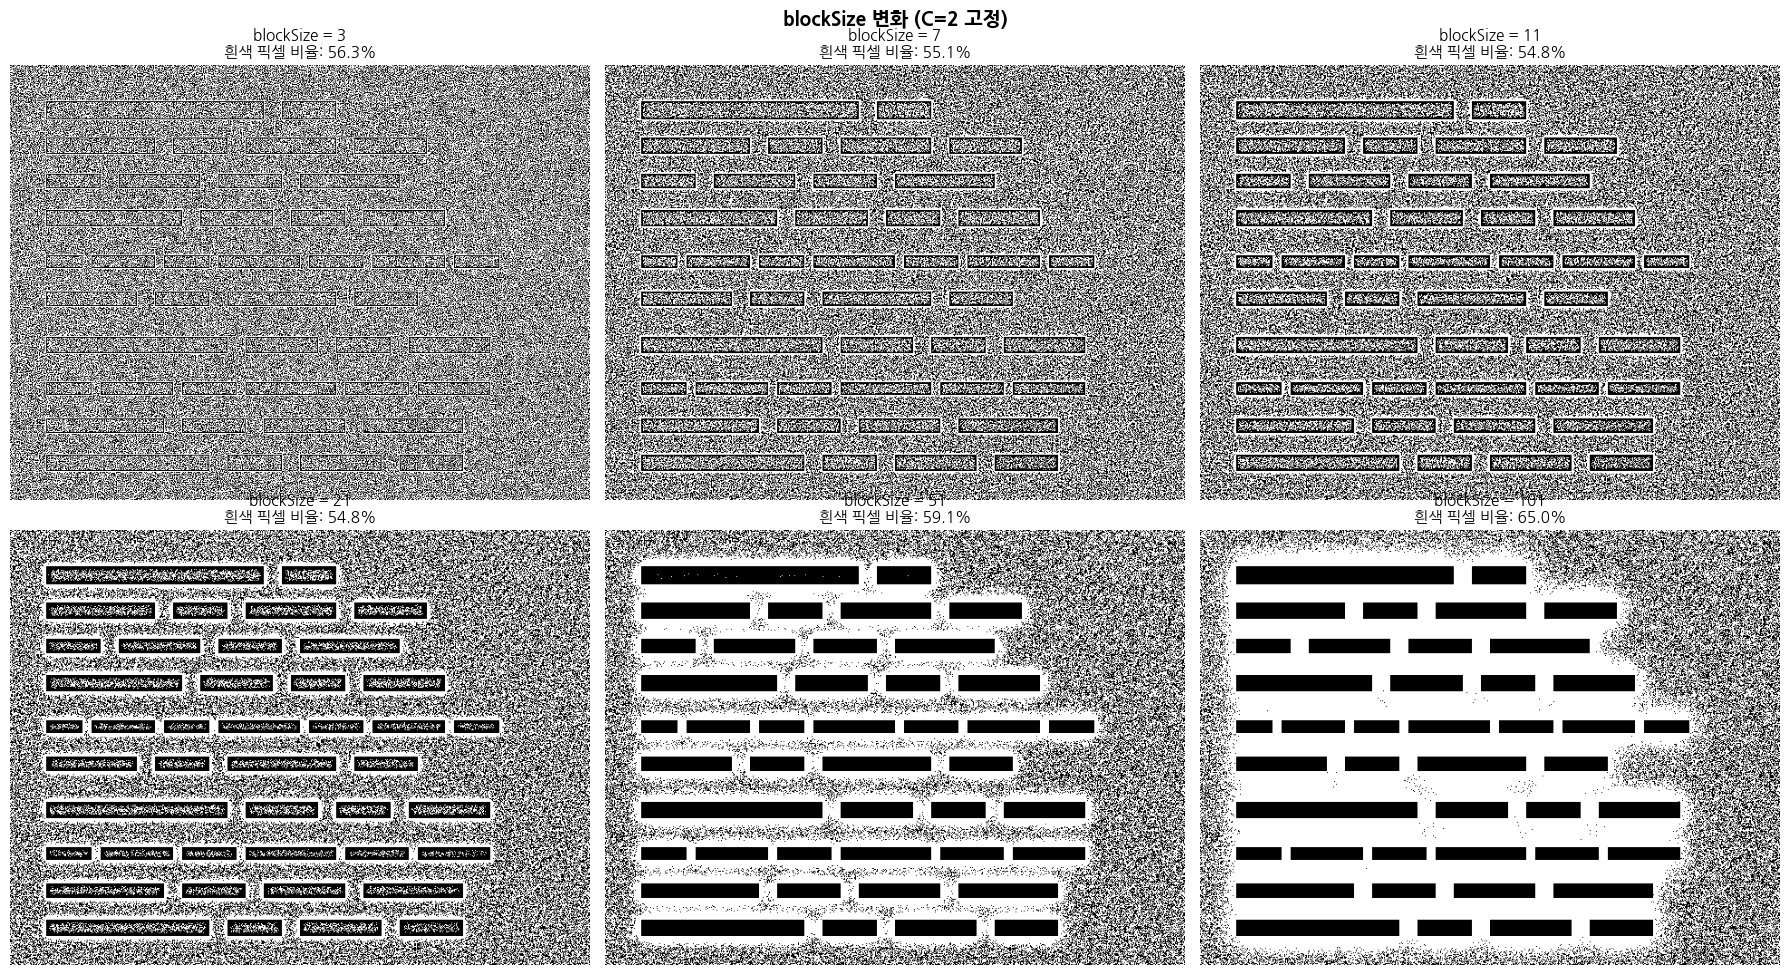

blockSize 해석 가이드
  3~7   : 노이즈 많음, 매우 세밀한 패턴
  11~21 : 일반적인 텍스트/패턴 검출에 적합
  51~   : 큰 조명 변화 대응, 세부 묻힘


In [5]:
# C는 고정(2), blockSize만 변화
C_FIXED = 2
block_sizes = [3, 7, 11, 21, 51, 101]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'blockSize 변화 (C={C_FIXED} 고정)', fontsize=14, fontweight='bold')

for ax, bs in zip(axes.flat, block_sizes):
    mask = cv2.adaptiveThreshold(
        imgGray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=bs,
        C=C_FIXED
    )
    white_ratio = (mask == 255).sum() / mask.size * 100

    ax.imshow(mask, cmap='gray')
    ax.set_title(
        f'blockSize = {bs}\n'
        f'흰색 픽셀 비율: {white_ratio:.1f}%',
        fontsize=11
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('result_step2_blocksize.jpg', dpi=120, bbox_inches='tight')
plt.show()

print('blockSize 해석 가이드')
print('  3~7   : 노이즈 많음, 매우 세밀한 패턴')
print('  11~21 : 일반적인 텍스트/패턴 검출에 적합')
print('  51~   : 큰 조명 변화 대응, 세부 묻힘')

### [3]  값 변화에 따른 영향

- threshold = 이웃 영역 평균 - C
- C 크면 → threshold 낮아짐 → 더 많은 픽셀이 255(흰색) → 밝아짐
- C 작으면 → threshold 높아짐 → 더 많은 픽셀이 0(검정) → 어두워짐
- C 음수   → threshold가 평균보다 높아짐 → 대부분 검정


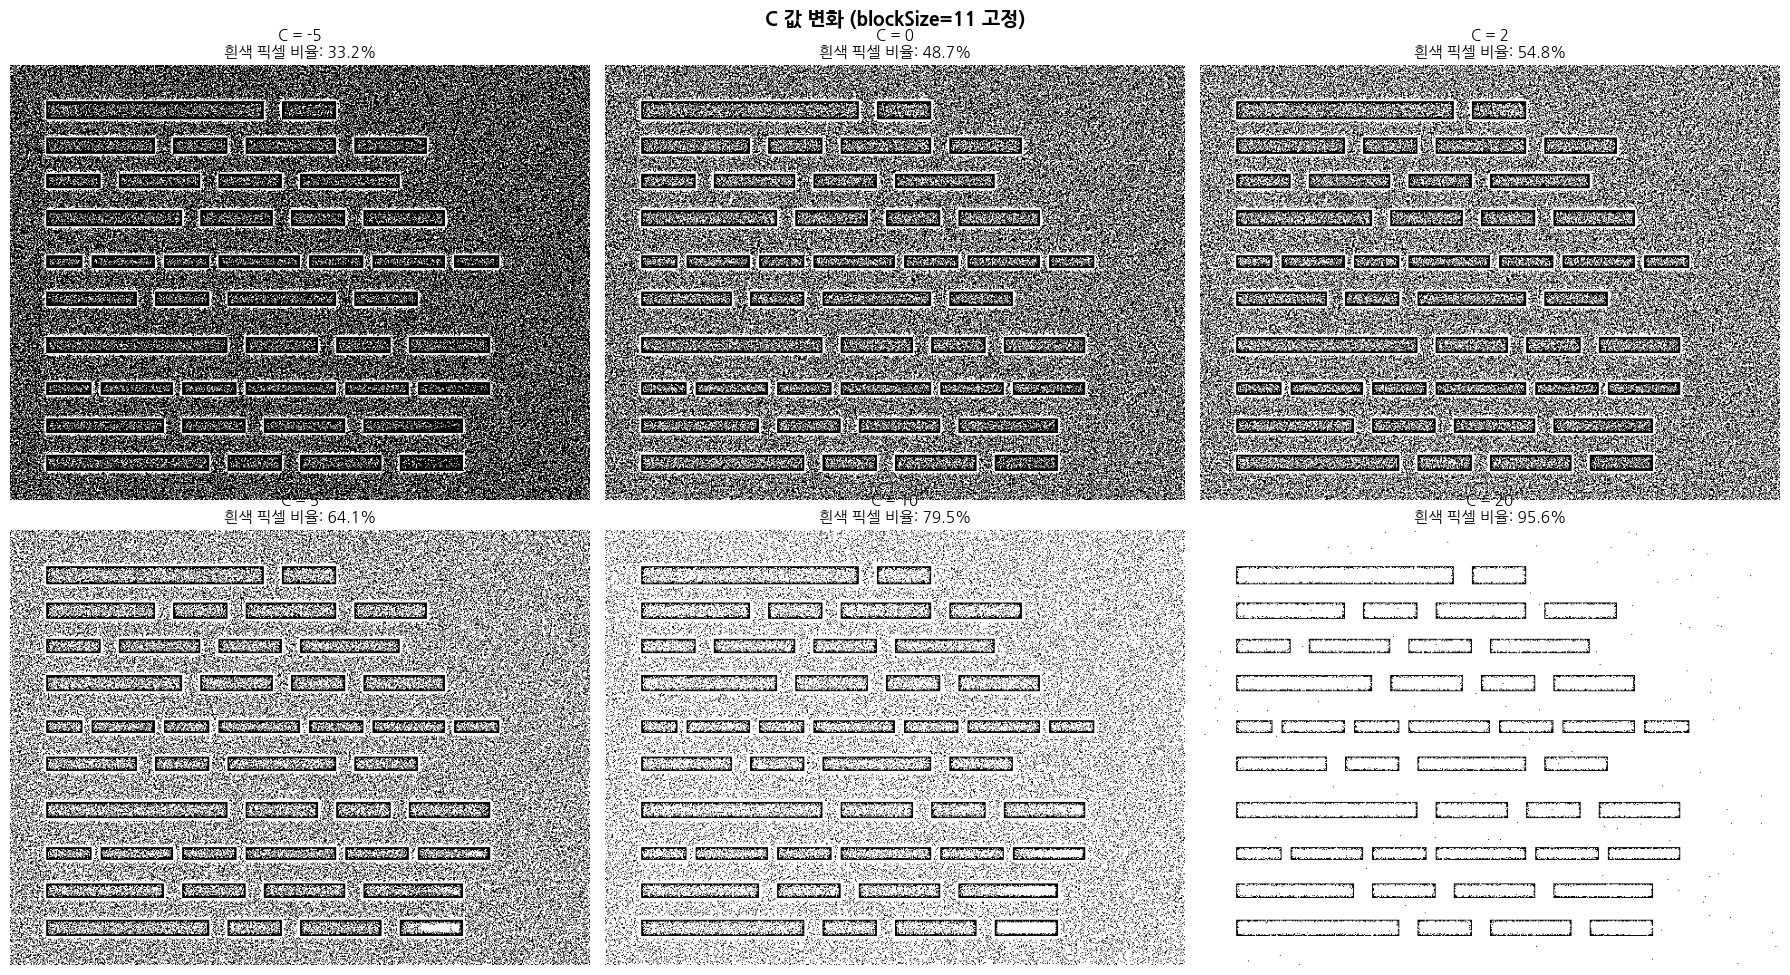

C 값 해석 가이드
  음수     : 임계값이 올라감 → 검정 많아짐 (과검출)
  0        : 순수하게 평균값이 임계값
  2~5      : 일반적인 텍스트 검출 권장값
  10 이상  : 임계값이 낮아짐 → 흰색 많아짐 (미검출)


In [6]:
# blockSize는 고정(11), C만 변화
BLOCK_FIXED = 11
c_values = [-5, 0, 2, 5, 10, 20]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'C 값 변화 (blockSize={BLOCK_FIXED} 고정)', fontsize=14, fontweight='bold')

for ax, c in zip(axes.flat, c_values):
    mask = cv2.adaptiveThreshold(
        imgGray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=BLOCK_FIXED,
        C=c
    )
    white_ratio = (mask == 255).sum() / mask.size * 100

    ax.imshow(mask, cmap='gray')
    ax.set_title(
        f'C = {c}\n'
        f'흰색 픽셀 비율: {white_ratio:.1f}%',
        fontsize=11
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('result_step3_c_value.jpg', dpi=120, bbox_inches='tight')
plt.show()

print('C 값 해석 가이드')
print('  음수     : 임계값이 올라감 → 검정 많아짐 (과검출)')
print('  0        : 순수하게 평균값이 임계값')
print('  2~5      : 일반적인 텍스트 검출 권장값')
print('  10 이상  : 임계값이 낮아짐 → 흰색 많아짐 (미검출)')

### [4] blockSize × C 조합 격자 비교

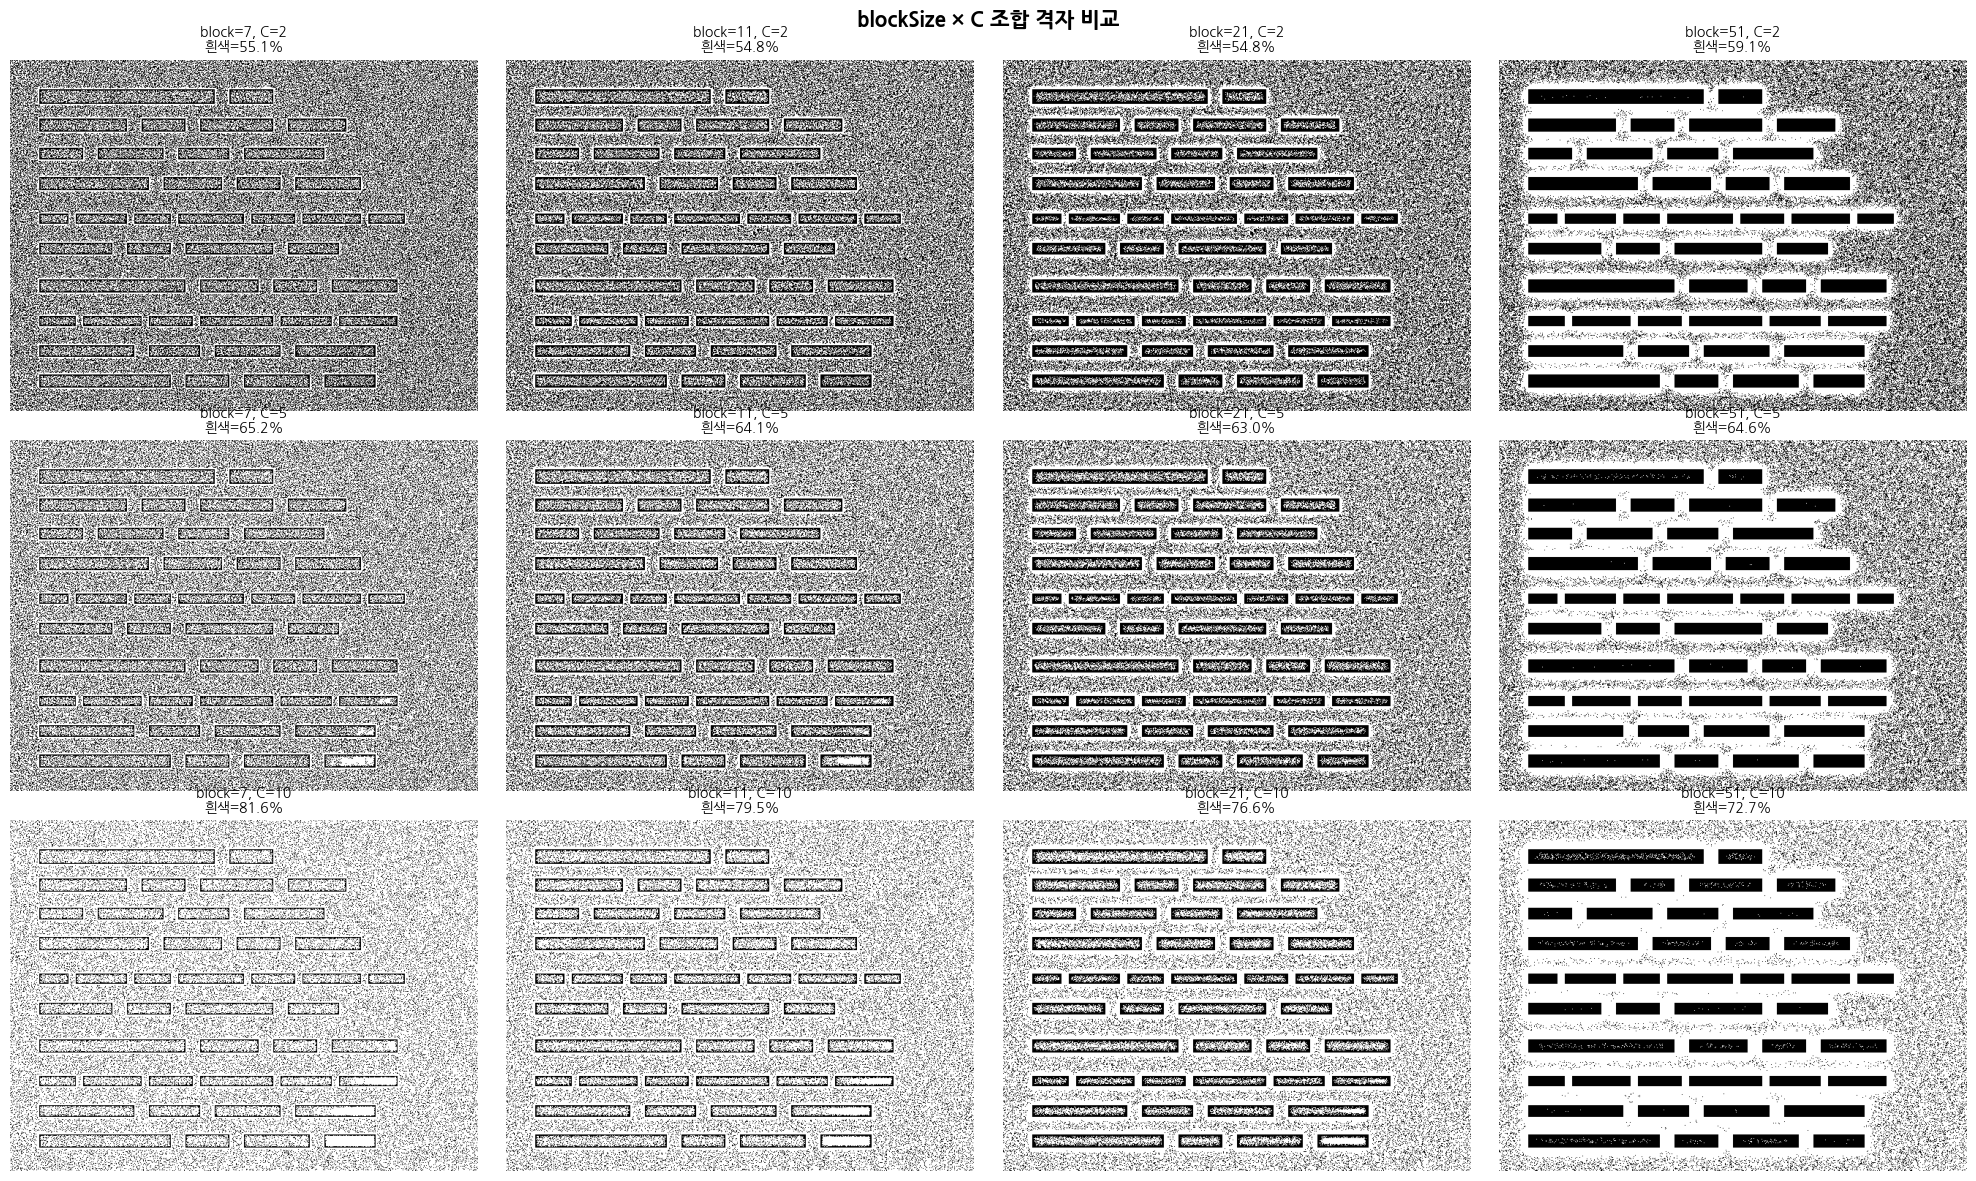

In [14]:
block_list = [7, 11, 21, 51]
c_list     = [2, 5, 10]

fig, axes = plt.subplots(
    len(c_list), len(block_list),
    figsize=(5 * len(block_list), 4 * len(c_list))
)
fig.suptitle('blockSize × C 조합 격자 비교', fontsize=15, fontweight='bold')

for row, c in enumerate(c_list):
    for col, bs in enumerate(block_list):
        mask = cv2.adaptiveThreshold(
            imgGray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            blockSize=bs,
            C=c
        )
        white_ratio = (mask == 255).sum() / mask.size * 100
        ax = axes[row, col]
        ax.imshow(mask, cmap='gray')
        ax.set_title(f'block={bs}, C={c}\n흰색={white_ratio:.1f}%', fontsize=10)
        ax.axis('off')

# 행/열 레이블
for row, c in enumerate(c_list):
    axes[row, 0].set_ylabel(f'C = {c}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('result_step4_grid.jpg', dpi=100, bbox_inches='tight')
plt.show()

### [4] MEAN vs GAUSSIAN 방식 비교

- ADAPTIVE_THRESH_MEAN_C     : 이웃 영역의 단순 평균
- ADAPTIVE_THRESH_GAUSSIAN_C : 이웃 영역의 가우시안 가중 평균 (중심 픽셀 가중치 높음)


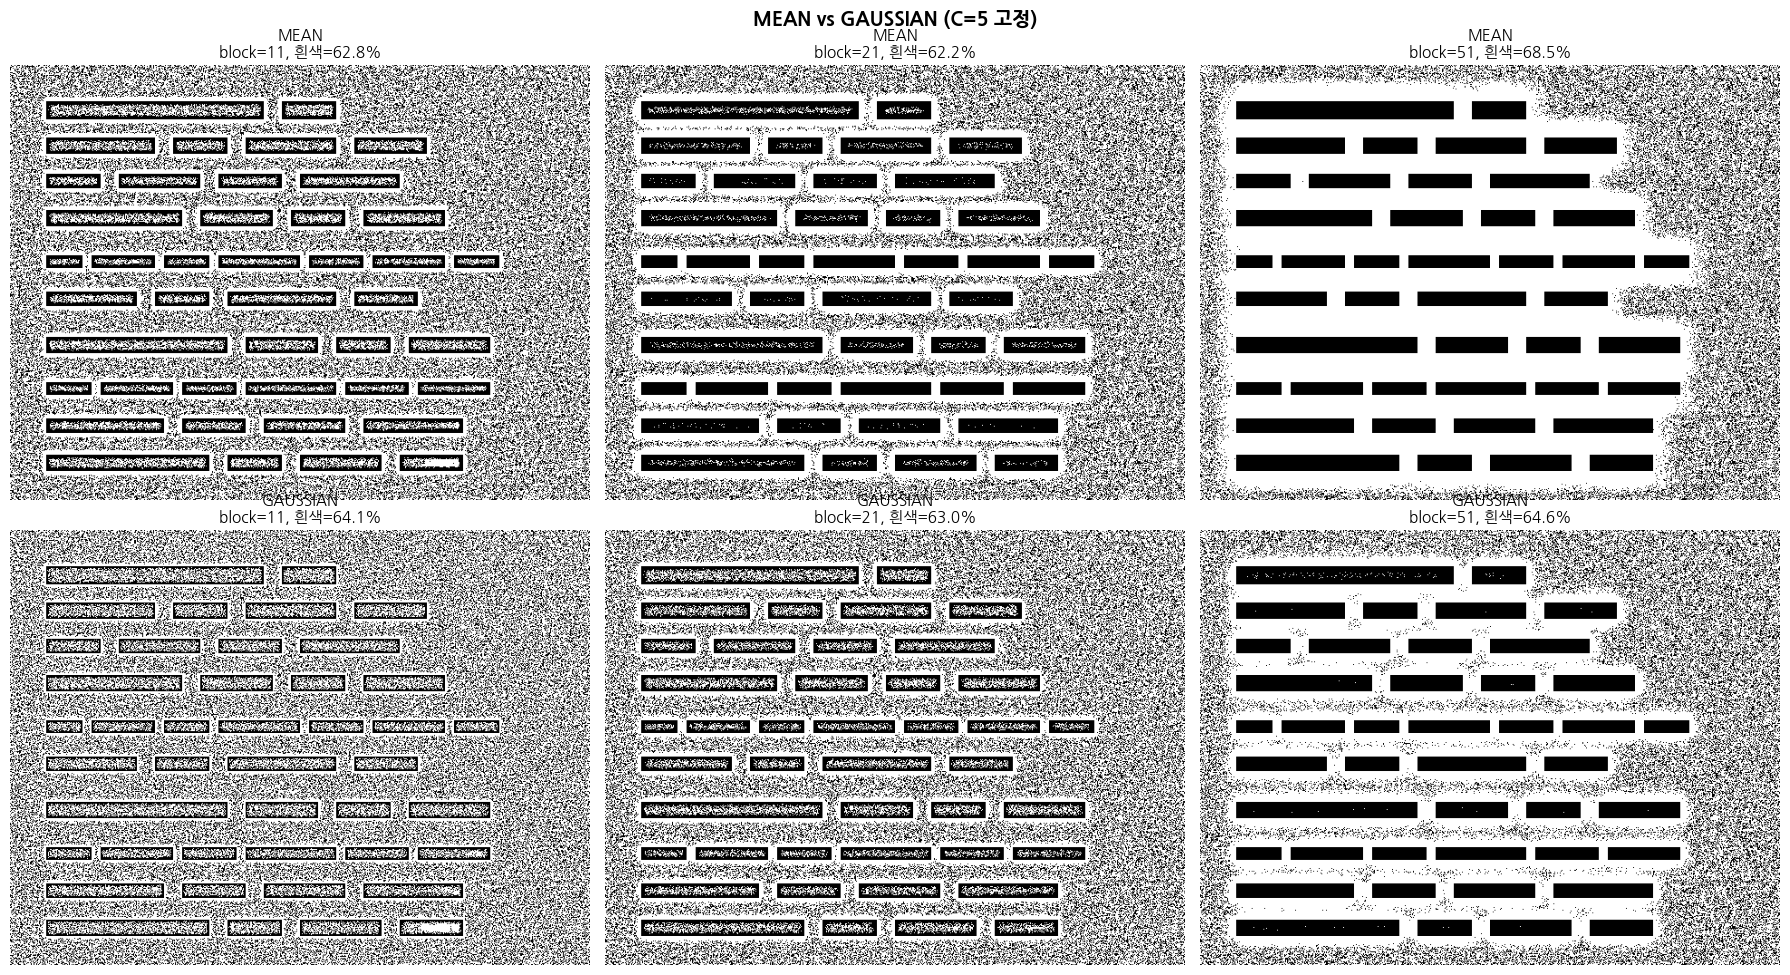

MEAN     : 빠르지만 경계선이 거칠 수 있음
GAUSSIAN : 부드러운 경계, 일반적으로 더 좋은 결과 (권장)


In [15]:
block_sizes_cmp = [11, 21, 51]
C_CMP = 5

fig, axes = plt.subplots(2, len(block_sizes_cmp), figsize=(18, 10))
fig.suptitle(f'MEAN vs GAUSSIAN (C={C_CMP} 고정)', fontsize=14, fontweight='bold')

methods = [
    (cv2.ADAPTIVE_THRESH_MEAN_C,     'MEAN'),
    (cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 'GAUSSIAN'),
]

for row, (method, method_name) in enumerate(methods):
    for col, bs in enumerate(block_sizes_cmp):
        mask = cv2.adaptiveThreshold(
            imgGray, 255,
            method,
            cv2.THRESH_BINARY,
            blockSize=bs,
            C=C_CMP
        )
        white_ratio = (mask == 255).sum() / mask.size * 100
        ax = axes[row, col]
        ax.imshow(mask, cmap='gray')
        ax.set_title(
            f'{method_name}\nblock={bs}, 흰색={white_ratio:.1f}%',
            fontsize=11
        )
        ax.axis('off')

plt.tight_layout()
plt.savefig('result_step5_mean_vs_gaussian.jpg', dpi=120, bbox_inches='tight')
plt.show()

print('MEAN     : 빠르지만 경계선이 거칠 수 있음')
print('GAUSSIAN : 부드러운 경계, 일반적으로 더 좋은 결과 (권장)')

### [6]  흰색 픽셀 비율 그래프로 정량 분석

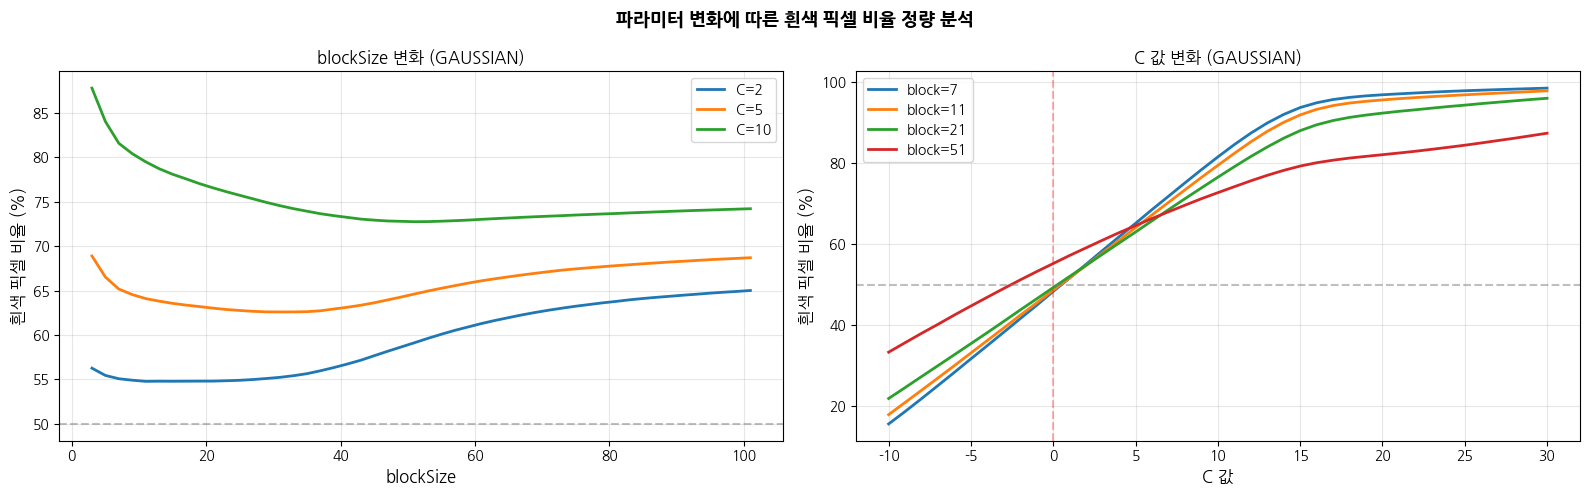

In [16]:
block_range = list(range(3, 102, 2))   # 3, 5, 7, ... 101
c_targets   = [2, 5, 10]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('파라미터 변화에 따른 흰색 픽셀 비율 정량 분석', fontsize=13, fontweight='bold')

# ── 그래프 1: C 고정, blockSize 변화
for c in c_targets:
    ratios = []
    for bs in block_range:
        m = cv2.adaptiveThreshold(
            imgGray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, bs, c
        )
        ratios.append((m == 255).sum() / m.size * 100)
    axes[0].plot(block_range, ratios, label=f'C={c}', linewidth=2)

axes[0].set_xlabel('blockSize', fontsize=12)
axes[0].set_ylabel('흰색 픽셀 비율 (%)', fontsize=12)
axes[0].set_title('blockSize 변화 (GAUSSIAN)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% 기준')

# ── 그래프 2: blockSize 고정, C 변화
c_range      = list(range(-10, 31))
block_targets = [7, 11, 21, 51]

for bs in block_targets:
    ratios = []
    for c in c_range:
        m = cv2.adaptiveThreshold(
            imgGray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, bs, c
        )
        ratios.append((m == 255).sum() / m.size * 100)
    axes[1].plot(c_range, ratios, label=f'block={bs}', linewidth=2)

axes[1].set_xlabel('C 값', fontsize=12)
axes[1].set_ylabel('흰색 픽셀 비율 (%)', fontsize=12)
axes[1].set_title('C 값 변화 (GAUSSIAN)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0,  color='red',  linestyle='--', alpha=0.3, label='C=0')

plt.tight_layout()
plt.savefig('result_step6_quantitative.jpg', dpi=120, bbox_inches='tight')
plt.show()

### [7] 최적 파라미터로 최종 결과 비교

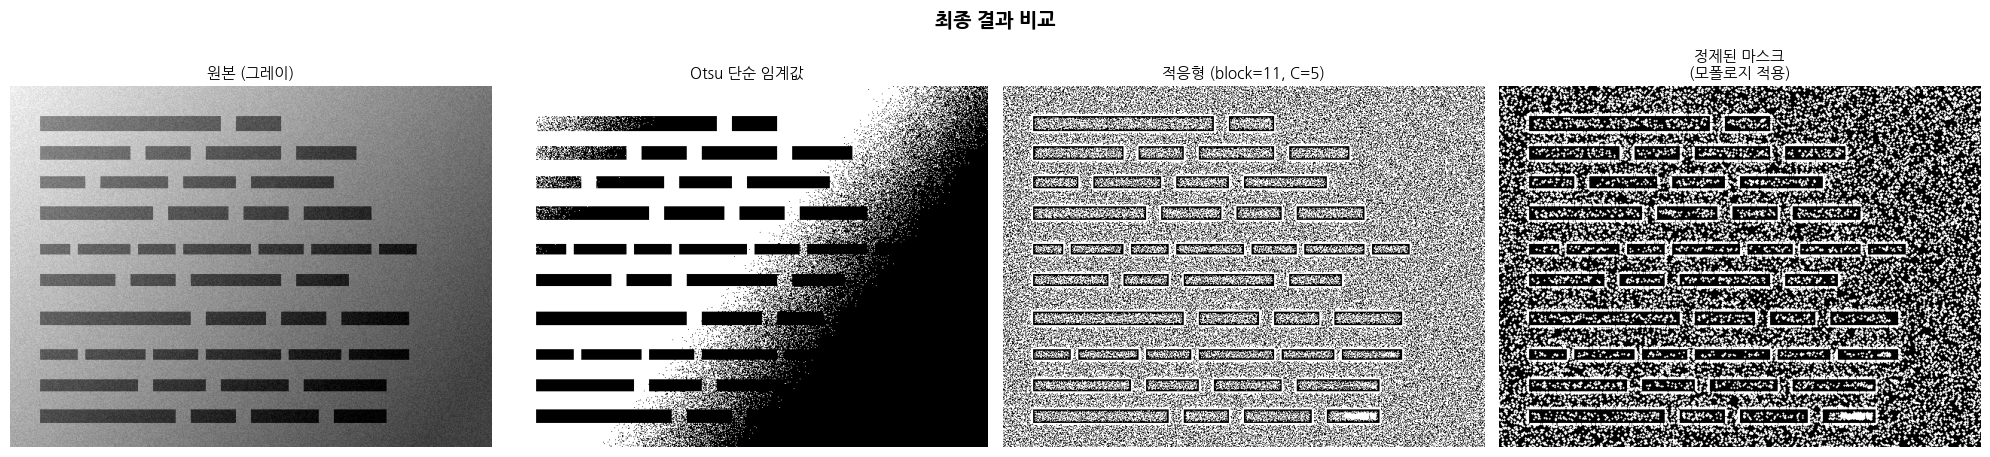

In [17]:
# ── 위 실험을 바탕으로 파라미터 직접 설정
BEST_BLOCK = 11    # ← 실험 결과 보고 수정
BEST_C     = 5     # ← 실험 결과 보고 수정

_, mask_otsu = cv2.threshold(imgGray, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

mask_best = cv2.adaptiveThreshold(
    imgGray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=BEST_BLOCK,
    C=BEST_C
)

# 모폴로지로 마스크 정제
kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mask_clean = cv2.morphologyEx(mask_best, cv2.MORPH_OPEN, kernel)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('최종 결과 비교', fontsize=14, fontweight='bold')

data = [
    (imgGray,    '원본 (그레이)',                          'gray'),
    (mask_otsu,  'Otsu 단순 임계값',                       'gray'),
    (mask_best,  f'적응형 (block={BEST_BLOCK}, C={BEST_C})', 'gray'),
    (mask_clean, '정제된 마스크\n(모폴로지 적용)',           'gray'),
]

for ax, (img, title, cmap) in zip(axes, data):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('result_step7_final.jpg', dpi=120, bbox_inches='tight')
plt.show()

### [ 파라미터 선택 가이드 요약 ]

| 상황 | blockSize 권장 | C 권장 |
|------|---------------|--------|
| 일반 텍스트 문서 | 11 ~ 21 | 2 ~ 5 |
| 노이즈 많은 이미지 | 21 ~ 51 | 5 ~ 10 |
| 세밀한 패턴 검출 | 3 ~ 7 | 2 ~ 3 |
| 심한 조명 불균일 | 51 ~ 101 | 5 ~ 10 |

- blockSize 크게  → 넓은 영역 기준 → 조명 불균일에 강함
- blockSize 작게  → 좁은 영역 기준 → 세밀한 패턴 검출

- C 크게          → 임계값 낮아짐 → 흰색 많아짐
- C 작게 / 음수   → 임계값 높아짐 → 검정 많아짐